# Análisis Exploratorio de Datos (EDA) - NASA C-MAPSS (FD001)
**Investigador:** Senior en Mantenimiento Predictivo y Experto en Deep Learning
**Objetivo:** Realizar un análisis exploratorio exhaustivo del dataset `FD001` para sentar las bases de una futura arquitectura de detección de anomalías (VAE/LSTM).

### 1. Carga y Preparación de Datos
Comenzamos cargando el conjunto de datos de entrenamiento `train_FD001.txt`. Según la documentación, el archivo no tiene cabecera y las columnas están separadas por espacios. Asignaremos los nombres correspondientes a cada columna.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual global
sns.set_theme(style='whitegrid', context='notebook', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

# Definir los nombres de las columnas según la documentación
column_names = [
    'unit_number', 'time_in_cycles', 'setting_1', 'setting_2', 'setting_3',
    'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9',
    'sensor_10', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16', 'sensor_17',
    'sensor_18', 'sensor_19', 'sensor_20', 'sensor_21'
]

# Cargar el dataset de entrenamiento
train_df = pd.read_csv('CMAPSSData/train_FD001.txt', sep='\\s+', header=None, names=column_names)

# Visualizar las primeras filas del dataframe
print("Forma del dataset de entrenamiento:", train_df.shape)
train_df.head()

Forma del dataset de entrenamiento: (20631, 26)


,unit_number,time_in_cycles,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


### 2. Ingeniería de Etiquetas: Cálculo del RUL (Remaining Useful Life)
El RUL es nuestro objetivo de predicción (ground truth). Para el conjunto de entrenamiento, el fallo ocurre en el último ciclo registrado para cada motor. Por tanto, podemos calcular el RUL en cualquier punto del tiempo `t` como la diferencia entre el último ciclo y `t`.

Además, aplicaremos una función de `clipping` (Piecewise Linear RUL). Como se establece en la literatura (Heimes, 2008), la degradación de un motor no es aparente en las primeras etapas de su vida operativa. Se establece un umbral de 125 ciclos y cualquier valor de RUL por encima de este umbral se 'clipea' a dicho valor.

In [2]:
# Calcular el ciclo máximo para cada unidad
max_cycles_df = train_df.groupby('unit_number')['time_in_cycles'].max().reset_index()
max_cycles_df.columns = ['unit_number', 'max_cycles']

# Unir la información de ciclos máximos con el dataframe original
train_df = pd.merge(train_df, max_cycles_df, on='unit_number', how='left')

# Calcular el RUL
train_df['RUL'] = train_df['max_cycles'] - train_df['time_in_cycles']

# Aplicar el clipping al RUL
RUL_THRESHOLD = 125
train_df['RUL'] = train_df['RUL'].clip(upper=RUL_THRESHOLD)

# Eliminar columnas auxiliares
train_df.drop(columns=['max_cycles'], inplace=True)

print("Dataset con la columna RUL y clipping aplicado:")
train_df[['unit_number', 'time_in_cycles', 'RUL']].head()

Dataset con la columna RUL y clipping aplicado:


,unit_number,time_in_cycles,RUL
0,1,1,125
1,1,2,125
2,1,3,125
3,1,4,125
4,1,5,125


### 3. Filtrado de Sensores (Feature Selection)
Los sensores que no varían a lo largo del tiempo no aportan información útil para predecir la degradación. Procedemos a identificar y eliminar aquellos sensores cuya desviación estándar es cero o cercana a cero.

De igual manera, los 'settings' o configuraciones operativas, para el dataset FD001, son constantes y no deben ser usados como features.

In [3]:
# Calcular la desviación estándar de los sensores y settings
sensor_std = train_df.loc[:, 'setting_1':'sensor_21'].std()

# Identificar columnas con varianza (y std) muy baja
constant_columns = sensor_std[sensor_std == 0].index.tolist()

print("Columnas con desviación estándar de cero:")
print(constant_columns)

# Generar la tabla con desviación estándar y rango
stats_df = pd.DataFrame({
    'Std Dev': sensor_std,
    'Range': train_df.loc[:, 'setting_1':'sensor_21'].max() - train_df.loc[:, 'setting_1':'sensor_21'].min()
})
print("\nEstadísticas de Sensores y Settings:")
print(stats_df.transpose()[constant_columns])

# Filtrar el dataframe, eliminando las columnas constantes
train_df_filtered = train_df.drop(columns=constant_columns)

print(f"\nDimensiones del dataset original: {train_df.shape}")
print(f"Dimensiones del dataset filtrado: {train_df_filtered.shape}")

Columnas con desviación estándar de cero:
['setting_3', 'sensor_1', 'sensor_10', 'sensor_18', 'sensor_19']

Estadísticas de Sensores y Settings:
         setting_3  sensor_1  sensor_10  sensor_18  sensor_19
Std Dev        0.0       0.0        0.0        0.0        0.0
Range          0.0       0.0        0.0        0.0        0.0

Dimensiones del dataset original: (20631, 27)
Dimensiones del dataset filtrado: (20631, 22)


### 4. Análisis de Correlación
Para entender la relación entre los sensores y la vida útil restante (RUL), calculamos la matriz de correlación. Utilizamos el coeficiente de correlación de **Spearman** en lugar del de Pearson, ya que es más robusto ante relaciones no lineales, que son comunes en procesos de degradación. Un valor cercano a +1 o -1 indica una fuerte relación monotónica, ideal para la selección de características.

Correlación de Spearman (valor absoluto) de los sensores con el RUL:
sensor_11    0.719903
sensor_4     0.704511
sensor_12    0.695352
sensor_7     0.682375
sensor_15    0.669752
sensor_21    0.659780
sensor_20    0.657609
sensor_17    0.635337
sensor_2     0.631109
sensor_3     0.608699
sensor_8     0.572671
sensor_13    0.572268
sensor_9     0.327305
sensor_14    0.208624
sensor_6     0.117298
sensor_5          NaN
sensor_16         NaN
Name: RUL, dtype: float64


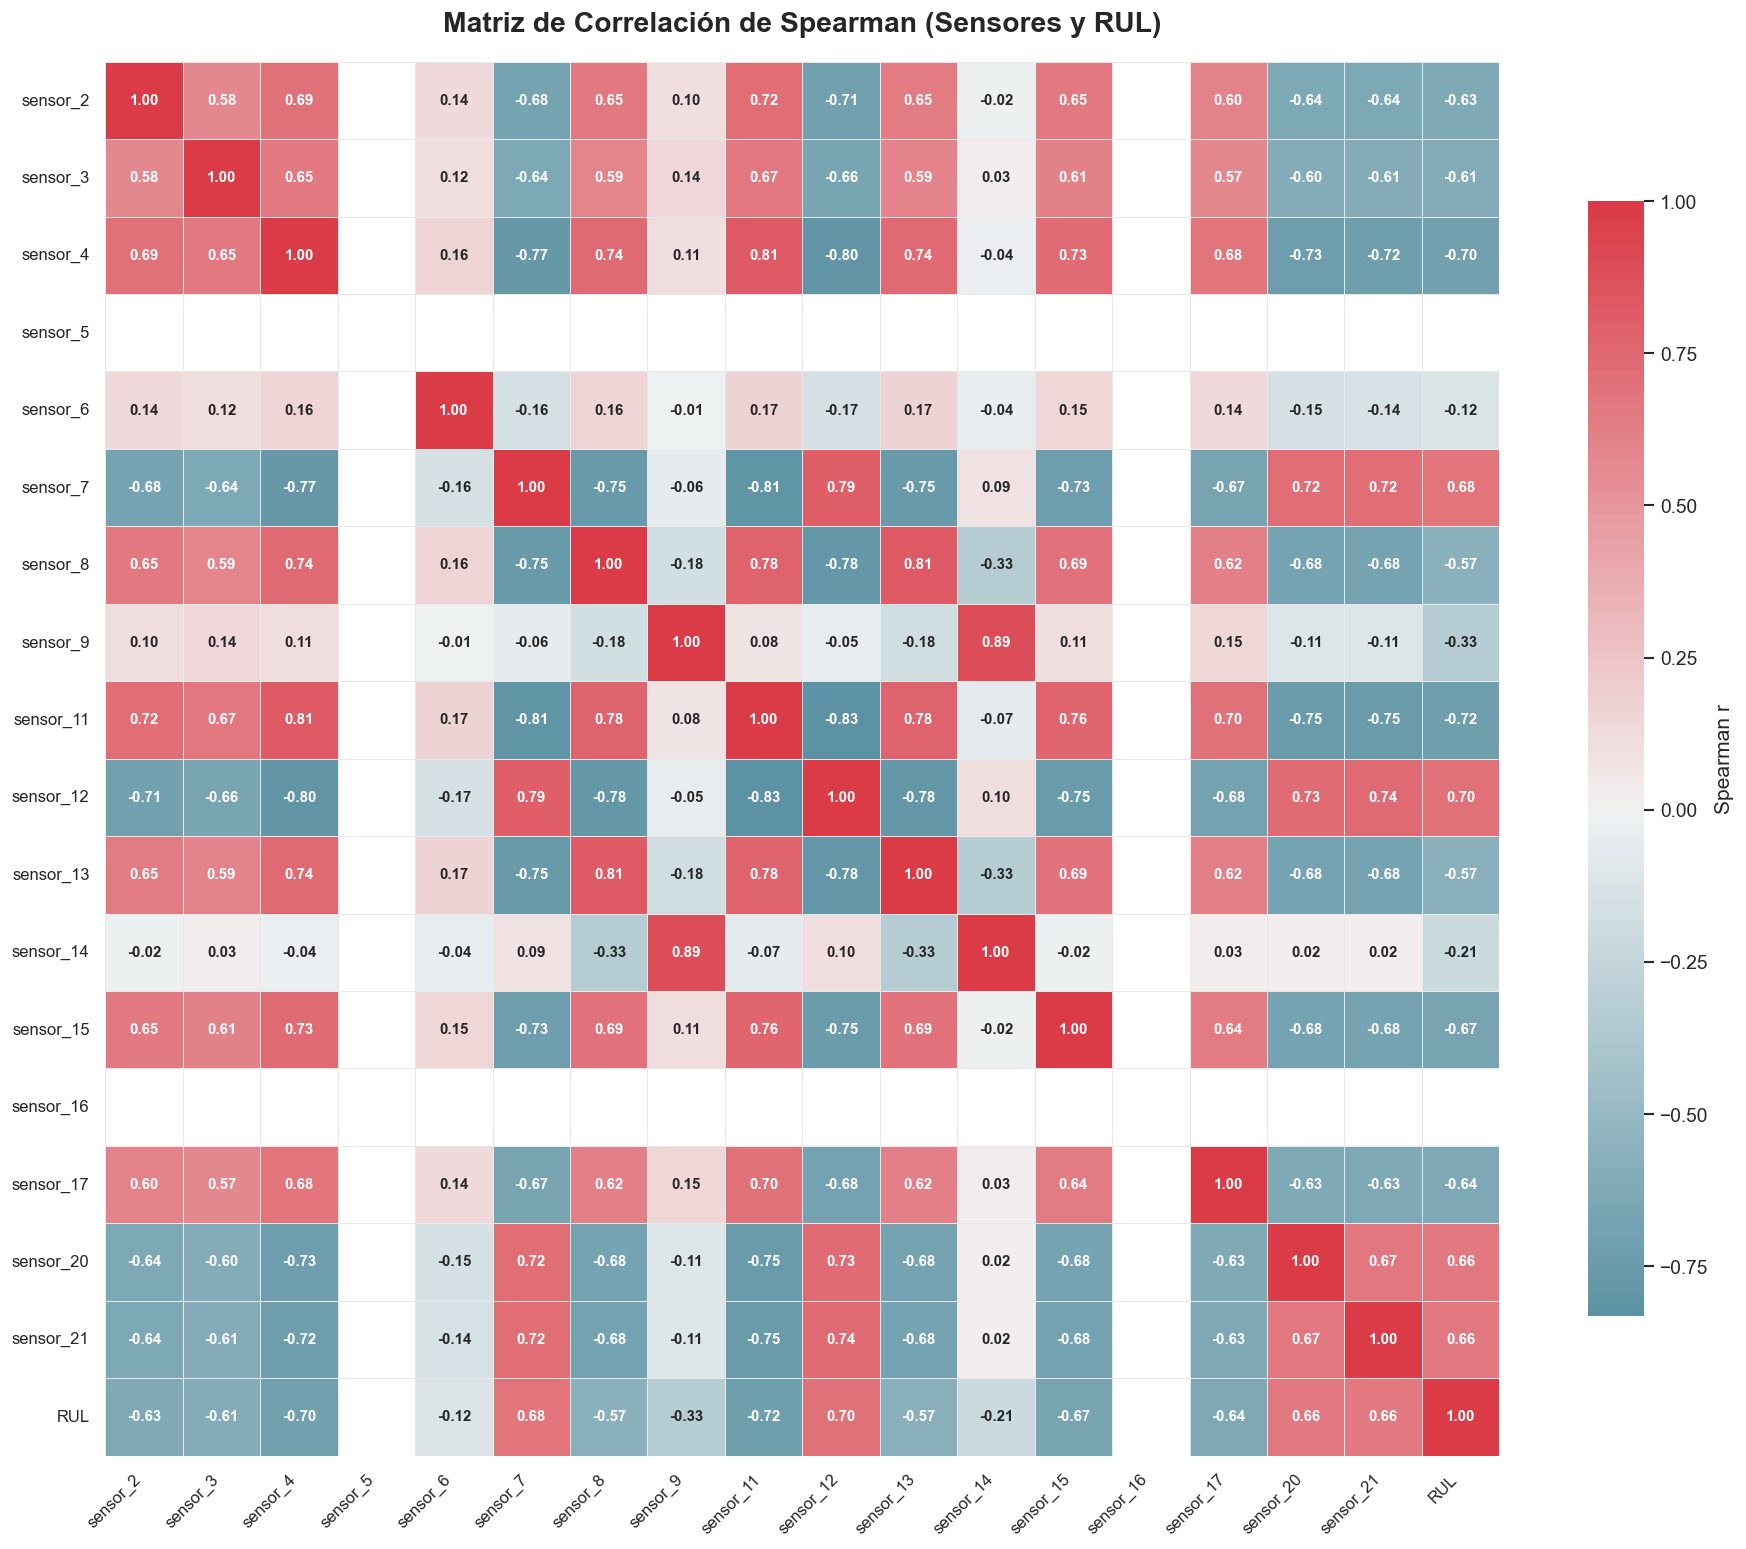

In [4]:
# Seleccionar solo las columnas de sensores y RUL para el análisis de correlación
sensor_columns = [col for col in train_df_filtered.columns if 'sensor' in col]
corr_df = train_df_filtered[sensor_columns + ['RUL']]

# Calcular la matriz de correlación de Spearman
correlation_matrix = corr_df.corr(method='spearman')

# Aislar la correlación de los sensores con el RUL y ordenarla
rul_correlation = correlation_matrix['RUL'].abs().sort_values(ascending=False)
print("Correlación de Spearman (valor absoluto) de los sensores con el RUL:")
print(rul_correlation[1:])

# --- Heatmap visual mejorado ---
sns.set_theme(style='white', context='notebook', font_scale=1.05)
fig, ax = plt.subplots(figsize=(16, 13))
cmap = sns.diverging_palette(220, 10, as_cmap=True)
sns.heatmap(
    correlation_matrix, annot=True, fmt='.2f', cmap=cmap, center=0,
    annot_kws={'size': 9, 'weight': 'bold'},
    linewidths=0.5, linecolor='#e8e8e8',
    square=True, cbar_kws={'shrink': 0.8, 'label': 'Spearman r'},
    ax=ax
)
ax.set_title('Matriz de Correlación de Spearman (Sensores y RUL)', fontsize=17, fontweight='bold', pad=18)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=10)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)
plt.tight_layout()
plt.show()

### 5. Visualización de Trayectorias de Degradación
Seleccionamos los 3 sensores con mayor correlación (en valor absoluto) con el RUL para visualizar su evolución. Graficamos las señales para 5 motores seleccionados aleatoriamente.

Se muestra la señal original con baja opacidad y una media móvil suavizada (ventana de 15 ciclos) para clarificar la tendencia de degradación de cada motor.

Top 3 sensores más correlacionados con el RUL: ['sensor_11', 'sensor_4', 'sensor_12']


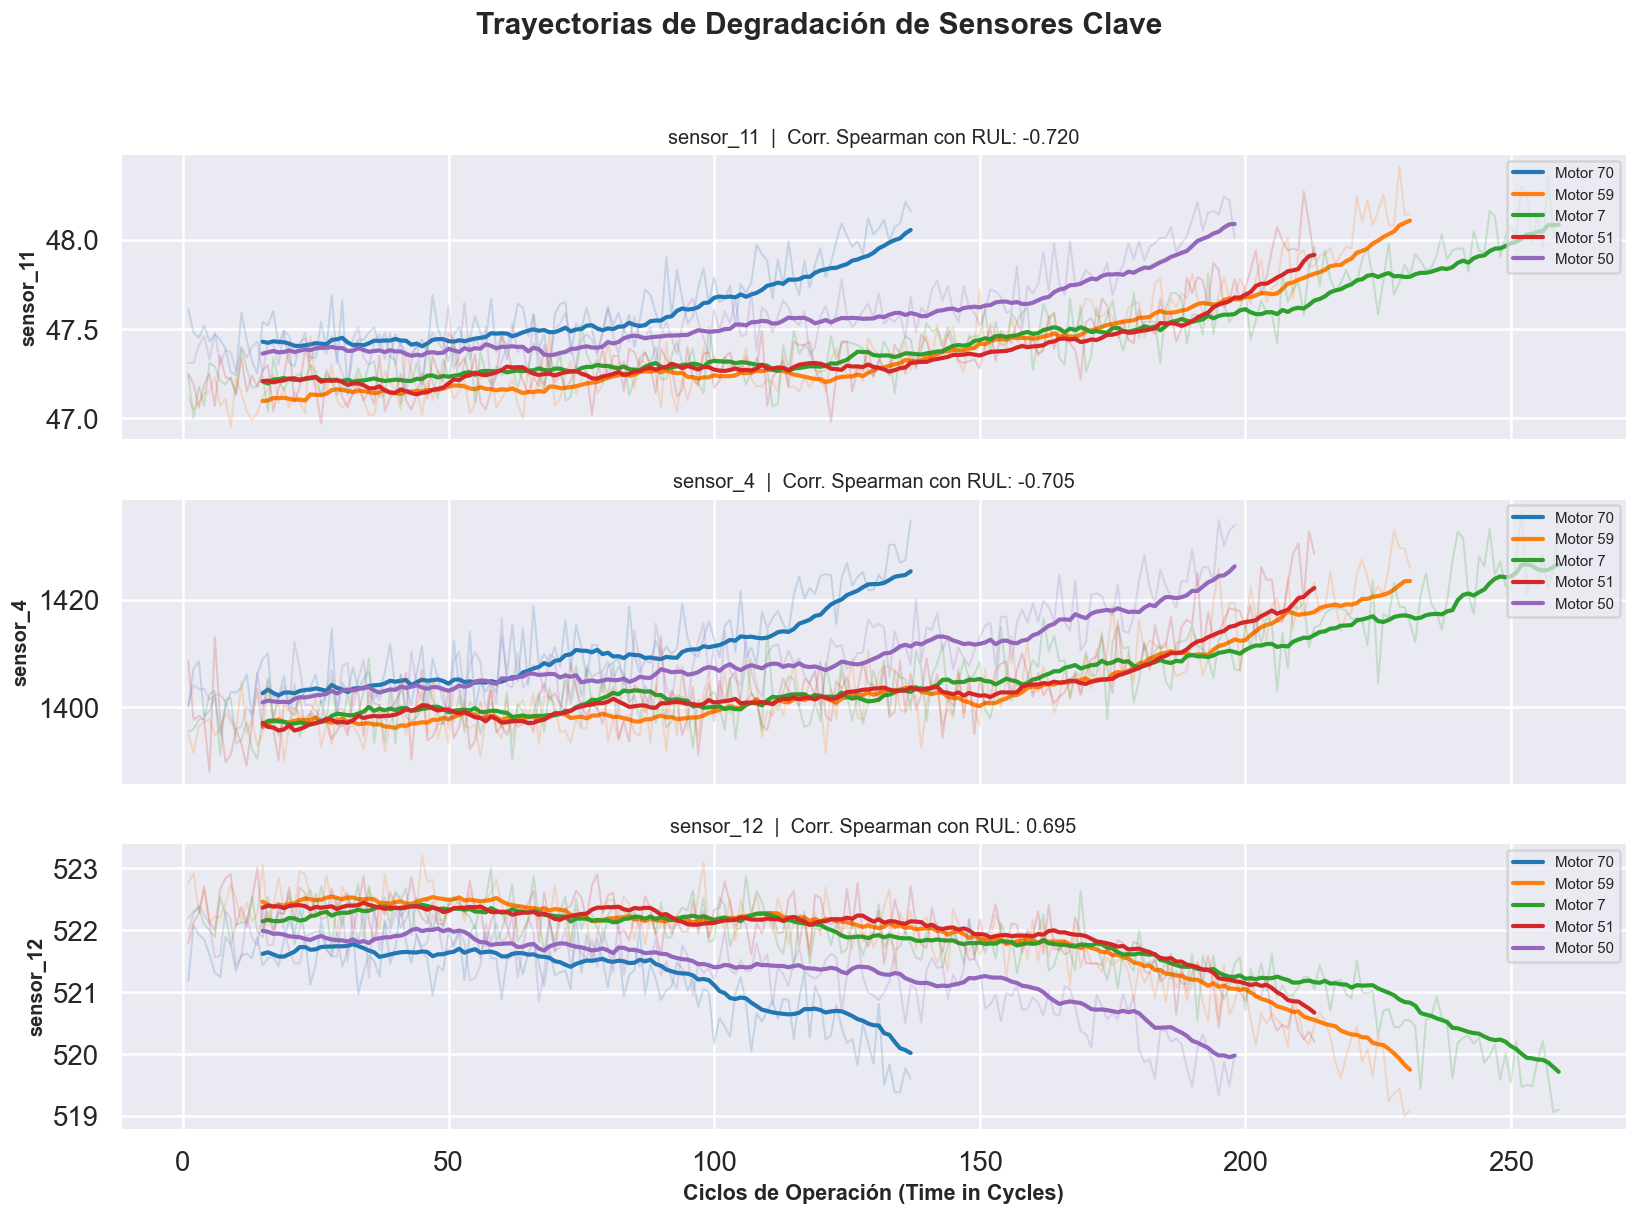


--- Conclusiones Técnicas ---
- sensor_11: tendencia ascendente al degradarse el motor (correlación=-0.720)
- sensor_4: tendencia ascendente al degradarse el motor (correlación=-0.705)
- sensor_12: tendencia descendente al degradarse el motor (correlación=0.695)


In [5]:
# Obtener los 3 sensores con mayor correlación (excluyendo el propio RUL)
top_sensors = rul_correlation[1:4].index.tolist()
print(f"Top 3 sensores más correlacionados con el RUL: {top_sensors}")

# Seleccionar 5 unidades de motor al azar
random_units = np.random.choice(train_df_filtered['unit_number'].unique(), 5, replace=False)
subset_df = train_df_filtered[train_df_filtered['unit_number'].isin(random_units)]

# --- Gráficas con estilo mejorado ---
sns.set_theme(style='darkgrid', context='talk')
palette = sns.color_palette('tab10', n_colors=len(random_units))
fig, axes = plt.subplots(len(top_sensors), 1, figsize=(14, 10), sharex=True)
fig.suptitle('Trayectorias de Degradación de Sensores Clave', fontsize=18, fontweight='bold', y=1.02)

for i, sensor in enumerate(top_sensors):
    ax = axes[i]
    for j, unit in enumerate(random_units):
        unit_data = subset_df[subset_df['unit_number'] == unit]
        # Señal original con baja opacidad
        ax.plot(unit_data['time_in_cycles'], unit_data[sensor],
                color=palette[j], alpha=0.2, linewidth=1.2)
        # Media móvil suavizada
        ax.plot(unit_data['time_in_cycles'], unit_data[sensor].rolling(window=15).mean(),
                color=palette[j], linewidth=2.5, label=f'Motor {unit}')
    corr_val = correlation_matrix.loc[sensor, 'RUL']
    ax.set_ylabel(sensor, fontsize=12, fontweight='bold')
    ax.set_title(f'{sensor}  |  Corr. Spearman con RUL: {corr_val:.3f}', fontsize=12)
    ax.legend(loc='upper right', fontsize=9, framealpha=0.7)

axes[-1].set_xlabel('Ciclos de Operación (Time in Cycles)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Conclusiones automáticas por sensor
print("\n--- Conclusiones Técnicas ---")
for sensor in top_sensors:
    correlation_value = correlation_matrix.loc[sensor, 'RUL']
    direction = 'ascendente' if correlation_value < 0 else 'descendente'
    print(f"- {sensor}: tendencia {direction} al degradarse el motor (correlación={correlation_value:.3f})")

### 6. Análisis de Condiciones Operativas
La solicitud original incluía un análisis de las condiciones operativas (los 6 regímenes de vuelo) para los datasets FD002 y FD004. Como se indica en la documentación (`readme.txt`) y se confirmó en nuestro análisis de varianza (donde `setting_1`, `setting_2` y `setting_3` fueron eliminados por ser constantes), el dataset **FD001 opera bajo una única condición operativa (nivel del mar)**.

Por lo tanto, este análisis no es aplicable a FD001. Se realizaría en un análisis posterior de los datasets más complejos (FD002/FD004), donde la interacción entre los regímenes de vuelo y la degradación del sensor es un factor crucial a modelar.